# Thử cho Train trước nè

In [6]:
import os, pandas as pd
import torch
import numpy as np
import pandas as pd
import os, json
import logging
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import gc
import pyarrow.parquet as pq
from collections import defaultdict
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import re
import json

outputLabel = ["output_0","output_1","output_2","output_3","output_4","output_5"]
outputRegressLabel = ["lightning_0", "lightning_1", "lightning_2", "lightning_3", "lightning_4", "lightning_5"]
startPeriod      = -6
endPeriod        =  6
startPeriodTrain = -6
endPeriodTrain   =  0

bandName = ['B09B','B10B','B11B','B12B','B14B','B16B','I2B','I4B','IRB','WVB', 'NDVI','Dem_value']

bandType = [
    f"{band}_t{('-' + str(-i)) if i < 0 else ('+' + str(i))}" if (band != "Dem_value" and band != "DEMIsLand") else band
    for i in range(startPeriod, endPeriod)
    for band in bandName
]

bandTypeTrain = [
    f"{band}_t{('-' + str(-i)) if i < 0 else ('+' + str(i))}" if (band != "Dem_value" and band != "DEMIsLand") else band
    for i in range(startPeriodTrain, endPeriodTrain)
    for band in bandName
]

In [11]:
band_groups = defaultdict(list)
for col in bandName:
    band_groups[col].append('output_0')

for col in bandTypeTrain:
    if col in ("Dem_value", "DEMIsLand"):
        band_groups[col].append(col)
        continue
    m = re.match(r"^(.+)_t[+\-]\d+$", col)
    if m:
        band_groups[m.group(1)].append(col)
band_groups

defaultdict(list,
            {'B09B': ['output_0',
              'B09B_t-6',
              'B09B_t-5',
              'B09B_t-4',
              'B09B_t-3',
              'B09B_t-2',
              'B09B_t-1'],
             'B10B': ['output_0',
              'B10B_t-6',
              'B10B_t-5',
              'B10B_t-4',
              'B10B_t-3',
              'B10B_t-2',
              'B10B_t-1'],
             'B11B': ['output_0',
              'B11B_t-6',
              'B11B_t-5',
              'B11B_t-4',
              'B11B_t-3',
              'B11B_t-2',
              'B11B_t-1'],
             'B12B': ['output_0',
              'B12B_t-6',
              'B12B_t-5',
              'B12B_t-4',
              'B12B_t-3',
              'B12B_t-2',
              'B12B_t-1'],
             'B14B': ['output_0',
              'B14B_t-6',
              'B14B_t-5',
              'B14B_t-4',
              'B14B_t-3',
              'B14B_t-2',
              'B14B_t-1'],
             'B16B': ['outp

In [7]:
TRAIN_DATA_DIR = "/sdd/Dubaoset/src/Phong/Model/data/trainClean/"

In [8]:
list_file = [os.path.join(TRAIN_DATA_DIR, file) for file in os.listdir(TRAIN_DATA_DIR) if file.endswith('.parquet')]
listFile = list_file

In [9]:
listFile

['/sdd/Dubaoset/src/Phong/Model/data/trainClean/merged_data_part_0.parquet',
 '/sdd/Dubaoset/src/Phong/Model/data/trainClean/merged_data_part_10.parquet',
 '/sdd/Dubaoset/src/Phong/Model/data/trainClean/merged_data_part_15.parquet',
 '/sdd/Dubaoset/src/Phong/Model/data/trainClean/merged_data_part_20.parquet',
 '/sdd/Dubaoset/src/Phong/Model/data/trainClean/merged_data_part_25.parquet',
 '/sdd/Dubaoset/src/Phong/Model/data/trainClean/merged_data_part_30.parquet',
 '/sdd/Dubaoset/src/Phong/Model/data/trainClean/merged_data_part_35.parquet',
 '/sdd/Dubaoset/src/Phong/Model/data/trainClean/merged_data_part_40.parquet',
 '/sdd/Dubaoset/src/Phong/Model/data/trainClean/merged_data_part_5.parquet']

# Code For Train

Đang xử lý Train cho Band: B09B...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Đang xử lý Train cho Band: B10B...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Đang xử lý Train cho Band: Dem_value...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

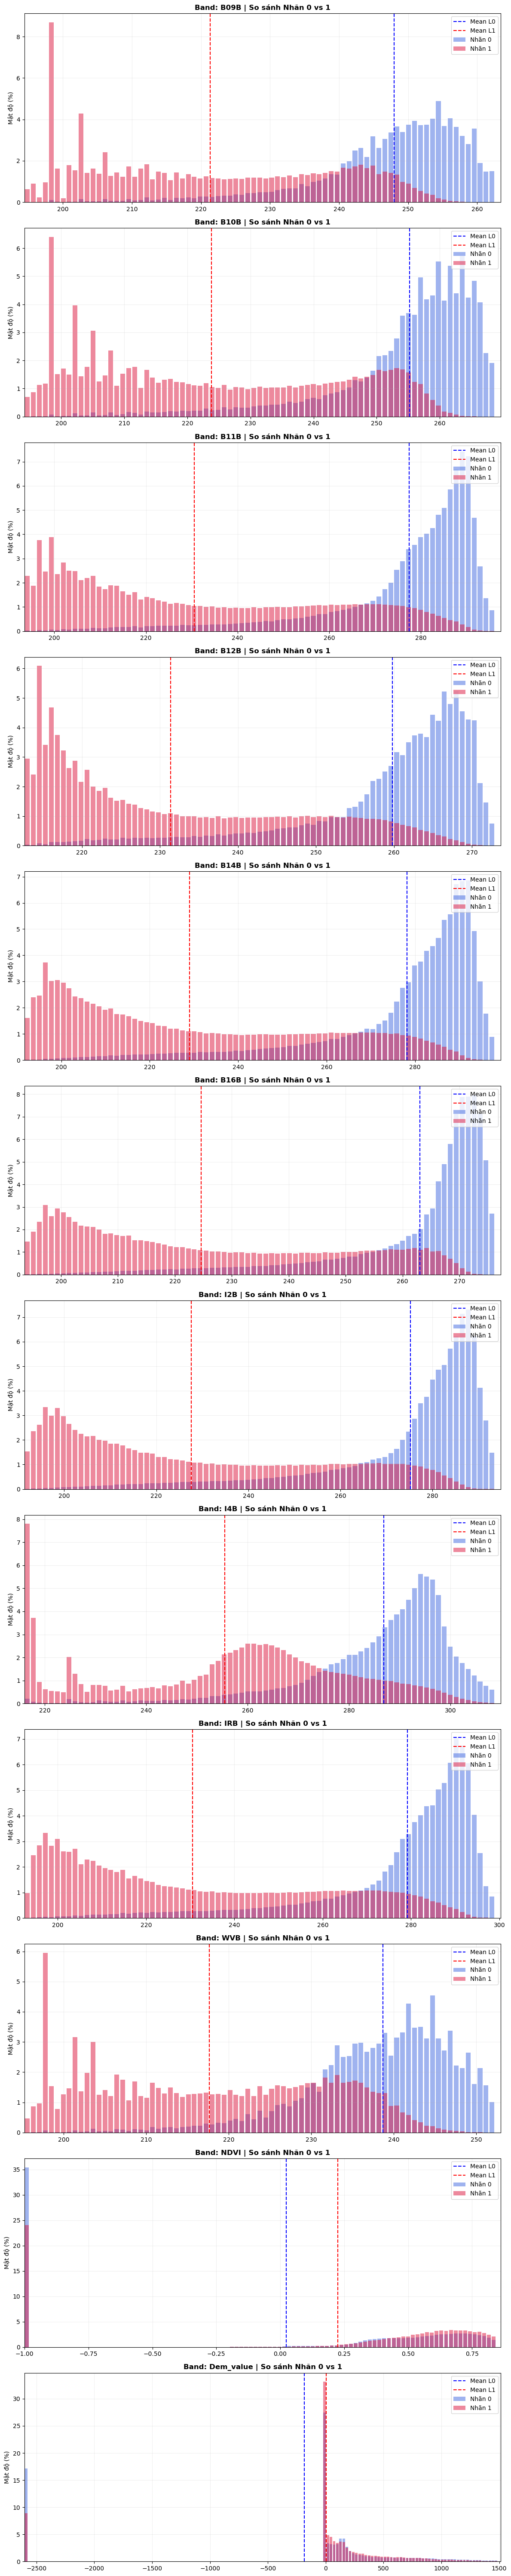

In [7]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import re
import json

# ── 1. Thiết lập kết nối ──
con = duckdb.connect()
con.execute("SET memory_limit='30GB'")
con.execute("SET threads=8")

# Giả định listFile và bandTypeTrain đã được định nghĩa
file_list_str = ", ".join([f"'{f}'" for f in listFile])

band_groups = defaultdict(list)
for col in bandTypeTrain:
    if col in ("Dem_value", "DEMIsLand"):
        band_groups[col].append(col)
        continue
    m = re.match(r"^(.+)_t[+\-]\d+$", col)
    if m:
        band_groups[m.group(1)].append(col)

# Biến để lưu trữ thông số chi tiết cho JSON và Histogram
detailed_stats_json = {}
hist_results = {}

# ── 2. Tính toán Stats & Histogram (Mật độ) ──
for band_name, cols in band_groups.items():
    print(f"Đang xử lý Train cho Band: {band_name}...")
    
    union_parts = "\n    UNION ALL\n    ".join([
        f'SELECT "{c}" AS val, "output_0" AS label FROM read_parquet([{file_list_str}])'
        for c in cols
    ])
    
    # Bước 2.1: Tính Stats chi tiết từng nhãn (Giữ nguyên)
    stats_label_query = f"""
    SELECT
        label,
        COUNT(*) AS total_rows,
        MIN(val) AS min_val,
        MAX(val) AS max_val,
        AVG(val) AS mean_val,
        APPROX_QUANTILE(val, 0.5) AS median_val,
        APPROX_QUANTILE(val, 0.02) AS p2,
        APPROX_QUANTILE(val, 0.98) AS p98
    FROM ({union_parts})
    WHERE val IS NOT NULL
    GROUP BY label
    """
    s_label_df = con.execute(stats_label_query).df().set_index('label')

    band_info = {}
    for lbl in [0, 1]:
        if lbl in s_label_df.index:
            row = s_label_df.loc[lbl]
            band_info[f"label_{lbl}"] = {
                'total_rows': int(row['total_rows']),
                'min': float(row['min_val']),
                'max': float(row['max_val']),
                'p2': float(row['p2']),
                'p98': float(row['p98']),
                'mean': float(row['mean_val']),
                'median': float(row['median_val'])
            }

    # --- ĐIỂM SỬA 1: XÁC ĐỊNH THANG ĐO CHUẨN (GIỐNG VAL/TEST) ---
    train_p2_0 = band_info['label_0']['p2']
    train_p2_1 = band_info['label_1']['p2']
    train_p98_0 = band_info['label_0']['p98']
    train_p98_1 = band_info['label_1']['p98']
    
    scale_p2 = min(train_p2_0, train_p2_1)
    scale_p98 = max(train_p98_0, train_p98_1)
    val_range = scale_p98 - scale_p2
    
    # Lưu chuẩn này vào JSON Train để Val/Test sau này sử dụng
    band_info['train_scale_used'] = {'p2': scale_p2, 'p98': scale_p98}
    detailed_stats_json[band_name] = band_info

    # --- ĐIỂM SỬA 2: TÍNH HISTOGRAM DỰA TRÊN THANG ĐO NÀY ---
    n_bins = 100 if band_name == 'NDVI' else (150 if band_name == 'Dem_value' else 80)
        
    hist_label_query = f"""
    SELECT 
        label,
        floor((val - {scale_p2}) / (NULLIF({val_range}, 0)) * ({n_bins} - 1)) as bin_idx,
        COUNT(*) as cnt
    FROM ({union_parts})
    WHERE val BETWEEN {scale_p2} AND {scale_p98}
    GROUP BY 1, 2 ORDER BY 2
    """
    h_label_df = con.execute(hist_label_query).df()

    # --- ĐIỂM SỬA 3: TÍNH MẬT ĐỘ THEO TỔNG SỐ DÒNG (GIỐNG VAL/TEST) ---
    res_band = {'n_bins': n_bins, 'scale_p2': scale_p2, 'scale_p98': scale_p98}
    for lbl in [0, 1]:
        df_lbl = h_label_df[h_label_df['label'] == lbl].copy()
        total_lbl = band_info[f"label_{lbl}"]['total_rows']
        df_lbl['density_pct'] = df_lbl['cnt'] * 100.0 / total_lbl if total_lbl > 0 else 0
        res_band[f'df{lbl}'] = df_lbl
    
    hist_results[band_name] = res_band

# Lưu file JSON thống kê chi tiết cho cả 2 nhãn
with open("/sdd/Dubaoset/src/Thang/dataStatistic/Label/detailed_stats_by_label_3.json", "w") as f:
    json.dump(detailed_stats_json, f, indent=4)

fig, axes = plt.subplots(len(band_groups), 1, figsize=(12, 5 * len(band_groups)))
if len(band_groups) == 1: axes = [axes]

for ax, band_name in zip(axes, band_groups.keys()):
    res = hist_results[band_name]
    p2, p98 = res['scale_p2'], res['scale_p98']
    bin_width = (p98 - p2) / res['n_bins']
    
    centers0 = p2 + (res['df0']['bin_idx'] + 0.5) * bin_width
    centers1 = p2 + (res['df1']['bin_idx'] + 0.5) * bin_width

    ax.bar(centers0, res['df0']['density_pct'], width=bin_width * 0.8, color="royalblue", alpha=0.5, label="Nhãn 0")
    ax.bar(centers1, res['df1']['density_pct'], width=bin_width * 0.8, color="crimson", alpha=0.5, label="Nhãn 1")

    # Vẽ Mean riêng của 2 nhãn từ dữ liệu trong JSON
    ax.axvline(detailed_stats_json[band_name]['label_0']['mean'], color="blue", linestyle="--", label="Mean L0")
    ax.axvline(detailed_stats_json[band_name]['label_1']['mean'], color="red", linestyle="--", label="Mean L1")
    
    ax.set_xlim(p2, p98)
    ax.set_ylabel("Mật độ (%)")
    ax.set_title(f"Band: {band_name} | So sánh Nhãn 0 vs 1", fontsize=12, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("/sdd/Dubaoset/src/Thang/dataStatistic/Label/train_labels_comparison_3.png", dpi=150)
plt.show()

# Code for Val And Test

In [ ]:
for band_name, _ in band_groups.items():
    print(f"Đang xử lý {band_name}...")
    
    # Tạo logic trượt: Mỗi Output (0-5) ứng với cửa sổ 6 khung thời gian
    all_window_queries = []
    
    for i in range(6): # Lặp qua 6 output_idx
        label_col = f"output_{i}"
        
        # Tính toán mốc thời gian bắt đầu của cửa sổ cho output này
        # output_0: t-6 -> t-1
        # output_1: t-5 -> t-0
        # output_2: t-4 -> t+1...
        window_start = -6 + i
        window_end = window_start + 6 
        
        for t_val in range(window_start, window_end):
            # Xử lý tên cột thời gian (t-6, t+0, t+1...)
            if band_name in ("Dem_value", "DEMIsLand"):
                col_name = band_name
            else:
                t_str = f"t{('-' + str(-t_val)) if t_val < 0 else ('+' + str(t_val))}"
                col_name = f"{band_name}_{t_str}"
            
            # Tạo query con cho mốc thời gian t này ứng với nhãn i này
            query_part = f'SELECT "{col_name}" AS val, "{label_col}" AS label FROM read_parquet([{file_list_str}])'
            all_window_queries.append(query_part)

    # Gộp tất cả các cửa sổ lại thành một bảng dữ liệu phẳng
    union_parts = "\n    UNION ALL\n    ".join(all_window_queries)
    print(union_parts)
    break


In [1]:
VAL_PATH = "/sdd/Dubaoset/src/Phong/Model/data/unknown/clean_eval_data_6.parquet"

In [17]:
listFile = [VAL_PATH]

Đang phân tích Validation cho Band: B09B...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Đang phân tích Validation cho Band: B10B...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Đang phân tích Validation cho Band: Dem_value...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Hoàn thành! JSON lưu tại: /sdd/Dubaoset/src/Thang/dataStatistic/Label/val_detailed_stats.json


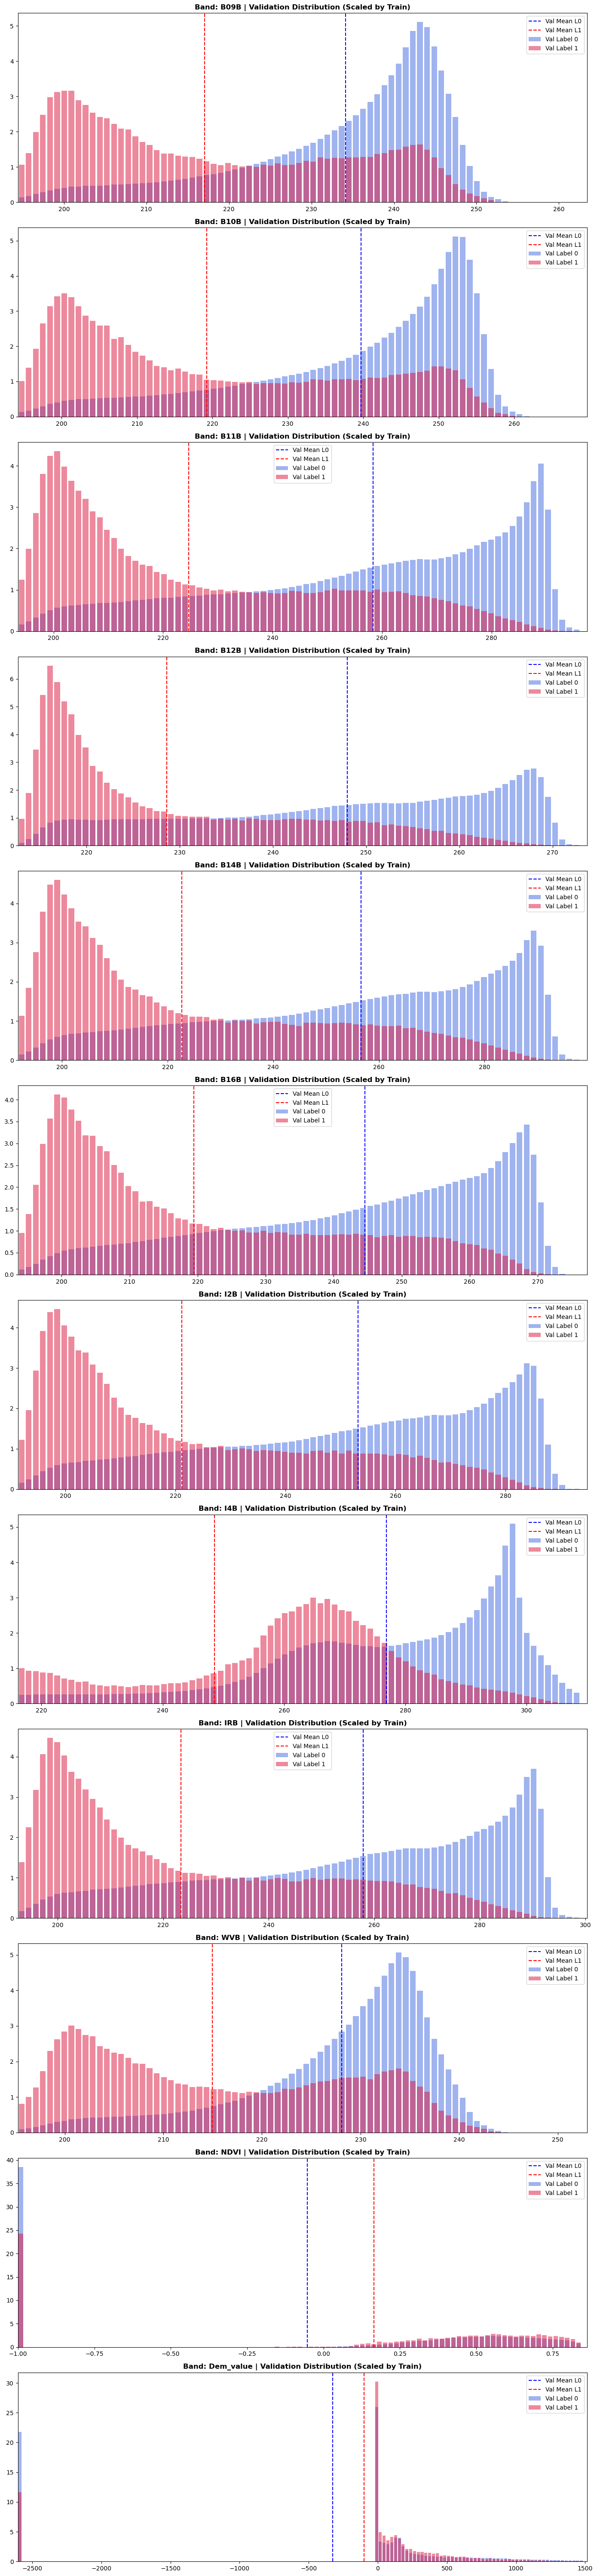

In [ ]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import json
import os

# ── 1. Thiết lập kết nối ──
con = duckdb.connect()
con.execute("SET memory_limit='30GB'")
con.execute("SET threads=8")

# Đường dẫn file
train_stats_path = '/sdd/Dubaoset/src/Thang/dataStatistic/NewTeacher/total_scales.json'
# Lấy chuẩn min max ở đây để vẽ histogram của Validation theo đúng thang đo của Train (Đảm bảo so sánh công bằng)
val_json_output = '/sdd/Dubaoset/src/Thang/dataStatistic/NewTeacher/Output/val_detailed_stats.json'
val_plot_output = '/sdd/Dubaoset/src/Thang/dataStatistic/NewTeacher/Output/val_comparison_report.png'

# Load thông số Train để lấy thang đo chuẩn
with open(train_stats_path, 'r') as f:
    train_stats_data = json.load(f)

# Giả định listFile đã được định nghĩa
file_list_str = ", ".join([f"'{f}'" for f in listFile])
bandName = ['B09B','B10B','B11B','B12B','B14B','B16B','I2B','I4B','IRB','WVB', 'NDVI','Dem_value']

detailed_stats_json = {}
hist_results = {}

# ── 2. Tính toán Stats & Histogram ──
for band in bandName:
    print(f"Đang phân tích Validation cho Band: {band}...")
    
    # 2.1 Tạo logic trượt cửa sổ (Sliding Window)
    all_window_queries = []
    for i in range(6):
        label_col = f"output_{i}"
        window_start = -6 + i
        window_end = window_start + 6 
        for t_val in range(window_start, window_end):
            if band in ("Dem_value", "DEMIsLand"):
                col_name = band
            else:
                t_str = f"t{('-' + str(-t_val)) if t_val < 0 else ('+' + str(t_val))}"
                col_name = f"{band}_{t_str}"
            
            all_window_queries.append(
                f'SELECT "{col_name}" AS val, "{label_col}" AS label FROM read_parquet([{file_list_str}])'
            )

    union_parts = "\n    UNION ALL\n    ".join(all_window_queries)
    
    # 2.2 Tính Stats thực tế của tập Validation (Để ghi vào JSON Val)
    stats_label_query = f"""
    SELECT
        label,
        COUNT(*) AS total_rows,
        MIN(val) AS min_val,
        MAX(val) AS max_val,
        AVG(val) AS mean_val,
    FROM ({union_parts})
    WHERE val IS NOT NULL
    GROUP BY label
    """
    s_label_df = con.execute(stats_label_query).df().set_index('label')
    
    # Lưu stats thực tế của Validation vào JSON
    val_band_stats = {}
    for lbl in [0, 1]:
        if lbl in s_label_df.index:
            row = s_label_df.loc[lbl]
            val_band_stats[f"label_{lbl}"] = {
                'total_rows': int(row['total_rows']),
                'min': float(row['min_val']),
                'max': float(row['max_val']),
                'mean': float(row['mean_val'])
            }
    detailed_stats_json[band] = val_band_stats

    # 2.3 Lấy khung đo (Scale) từ tập TRAIN đã load
    # Ta sử dụng P2 của label_1 và P98 của label_0 (hoặc ngược lại) để bao phủ như logic Global cũ
    train_p2_0 = train_stats_data[band]['label_0']['min']
    train_p2_1 = train_stats_data[band]['label_1']['min']
    train_p98_0 = train_stats_data[band]['label_0']['max']
    train_p98_1 = train_stats_data[band]['label_1']['max']

    # Thang đo chuẩn từ Train
    scale_p2 = min(train_p2_0, train_p2_1)
    scale_p98 = max(train_p98_0, train_p98_1)
    val_range = scale_p98 - scale_p2
    
    # Lưu scale vào JSON Val để sau này đối chiếu
    detailed_stats_json[band]['train_scale_used'] = {'p2': scale_p2, 'p98': scale_p98}

    # 2.4 Tính Histogram cho Validation dựa trên khung đo của Train
    n_bins = 100 if band == 'NDVI' else (150 if band == 'Dem_value' else 80)
        
    hist_sql = f"""
    SELECT 
        label,
        floor((val - {scale_p2}) / (NULLIF({val_range}, 0)) * ({n_bins} - 1)) as bin_idx,
        COUNT(*) as cnt
    FROM ({union_parts})
    WHERE val BETWEEN {scale_p2} AND {scale_p98}
    GROUP BY 1, 2 ORDER BY 2
    """
    h_df = con.execute(hist_sql).df()

    # Tách và tính % mật độ của Validation
    res_band = {'n_bins': n_bins, 'scale_p2': scale_p2, 'scale_p98': scale_p98}
    for lbl in [0, 1]:
        df_lbl = h_df[h_df['label'] == lbl].copy()
        # Dùng tổng rows của chính Validation để tính mật độ
        total_lbl = val_band_stats[f"label_{lbl}"]['total_rows']
        df_lbl['density_pct'] = df_lbl['cnt'] * 100.0 / total_lbl if total_lbl > 0 else 0
        res_band[f'df{lbl}'] = df_lbl
        
    hist_results[band] = res_band

# ── 3. Lưu file JSON & Vẽ đồ thị ──

# Lưu JSON Validation (Stats thật của Val)
with open(val_json_output, 'w') as f:
    json.dump(detailed_stats_json, f, indent=4)

# Vẽ đồ thị (Dùng khung X của Train)
fig, axes = plt.subplots(len(bandName), 1, figsize=(14, 5 * len(bandName)))
if len(bandName) == 1: axes = [axes]

for ax, band in zip(axes, bandName):
    res = hist_results[band]
    p2, p98 = res['scale_p2'], res['scale_p98']
    bin_width = (p98 - p2) / res['n_bins']
    
    # Vẽ Nhãn 0 (Val data)
    if not res['df0'].empty:
        c0 = p2 + (res['df0']['bin_idx'] + 0.5) * bin_width
        ax.bar(c0, res['df0']['density_pct'], width=bin_width*0.8, color="royalblue", alpha=0.5, label="Val Label 0")
    
    # Vẽ Nhãn 1 (Val data)
    if not res['df1'].empty:
        c1 = p2 + (res['df1']['bin_idx'] + 0.5) * bin_width
        ax.bar(c1, res['df1']['density_pct'], width=bin_width*0.8, color="crimson", alpha=0.5, label="Val Label 1")
    
    # Vẽ Mean thực của Validation
    ax.axvline(detailed_stats_json[band]['label_0']['mean'], color="blue", linestyle="--", label="Val Mean L0")
    ax.axvline(detailed_stats_json[band]['label_1']['mean'], color="red", linestyle="--", label="Val Mean L1")
    
    # Cố định trục X theo Train
    ax.set_xlim(p2, p98)
    ax.set_title(f"Band: {band} | Validation Distribution (Scaled by Train)", fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig(val_plot_output)
print(f"Hoàn thành! JSON lưu tại: {val_json_output}")

# Chưa chuẩn hóa
# Plot for all tập train val test luôn vẽ không chia nhãn | theo min max đã chọn nè oke
# chia 0-1 
# Đã chuẩn hóa
# Plot for all tập train val test luôn vẽ không chia nhãn | theo min max đã chọn nè oke
# chia 0-1 


# Chưa chuẩn hóa theo min max đã chọn

In [ ]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# ── 1. Thiết lập kết nối ──
con = duckdb.connect()
con.execute("SET memory_limit='30GB'")
con.execute("SET threads=8")

# Đường dẫn file
train_stats_path = '/sdd/Dubaoset/src/Thang/dataStatistic/NewTeacher/total_scales.json'
# val_json_output = '/sdd/Dubaoset/src/Thang/dataStatistic/NewTeacher/Output/val_detailed_stats.json'
val_plot_output = '/sdd/Dubaoset/src/Thang/dataStatistic/NewTeacher/Output/train_not_nor.png'

# Load thông số Train/Global để lấy thang đo chuẩn
with open(train_stats_path, 'r') as f:
    train_stats_data = json.load(f)

# Giả định listFile đã được định nghĩa
file_list_str = ", ".join([f"'{f}'" for f in listFile])
bandName = ['B09B','B10B','B11B','B12B','B14B','B16B','I2B','I4B','IRB','WVB', 'NDVI','Dem_value']

hist_results = {}
detailed_stats_json = {}

# ── 2. Tính toán Stats & Histogram ──
for band in bandName:
    print(f"Đang phân tích Band: {band}...")
    
    # 2.1 Tạo logic trượt cửa sổ (Sliding Window)
    all_window_queries = []
    for i in range(6):
        window_start = -6 + i
        window_end = window_start + 6 
        for t_val in range(window_start, window_end):
            if band in ("Dem_value", "DEMIsLand"):
                col_name = band
            else:
                t_str = f"t{('-' + str(-t_val)) if t_val < 0 else ('+' + str(t_val))}"
                col_name = f"{band}_{t_str}"
            
            # Không lấy cột label nữa vì ta muốn gộp chung
            all_window_queries.append(f'SELECT "{col_name}" AS val FROM read_parquet([{file_list_str}])')

    union_parts = "\n    UNION ALL\n    ".join(all_window_queries)

    # Lấy min/max chuẩn của band này từ JSON đã chuẩn bị
    min_val = train_stats_data[band]['min']
    max_val = train_stats_data[band]['max']
    val_range = max_val - min_val

    # Tính tổng số dòng để tính mật độ %
    total_count_query = f"SELECT COUNT(*) FROM ({union_parts}) WHERE val IS NOT NULL"
    total_rows = con.execute(total_count_query).fetchone()[0]

    # 2.2 Tính Histogram (Gộp chung, không phân nhãn)
    # Tăng n_bins lên 200 như bạn muốn để nhìn chi tiết hơn
    n_bins = 100 if band == 'NDVI' else (150 if band == 'Dem_value' else 200)
        
    hist_sql = f"""
    SELECT 
        floor((val - {min_val}) / (NULLIF({val_range}, 0)) * ({n_bins} - 1)) as bin_idx,
        COUNT(*) as cnt
    FROM ({union_parts})
    WHERE val BETWEEN {min_val} AND {max_val}
    GROUP BY 1 ORDER BY 1
    """
    h_df = con.execute(hist_sql).df()
    
    # Tính mật độ phần trăm
    h_df['density_pct'] = (h_df['cnt'] * 100.0 / total_rows) if total_rows > 0 else 0

    hist_results[band] = {
        'df': h_df, 
        'n_bins': n_bins, 
        'min': min_val, 
        'max': max_val,
        'total_rows': total_rows
    }

# ── 3. Vẽ đồ thị ──
fig, axes = plt.subplots(len(bandName), 1, figsize=(14, 5 * len(bandName)))
if len(bandName) == 1: axes = [axes]

for ax, band in zip(axes, bandName):
    res = hist_results[band]
    b_min, b_max = res['min'], res['max']
    bin_width = (b_max - b_min) / res['n_bins']
    
    # Tính tọa độ X cho các cột bar
    # centers = b_min + (bin_idx + 0.5) * bin_width
    centers = b_min + (res['df']['bin_idx'] + 0.5) * bin_width
    
    # Vẽ phân phối tổng thể
    ax.bar(centers, res['df']['density_pct'], width=bin_width * 0.9, color="steelblue", alpha=0.7, label="Distribution")
    
    # Cố định trục X theo chuẩn chung
    ax.set_xlim(b_min, b_max)
    ax.set_ylabel("Mật độ (%)")
    ax.set_title(f"Band: {band} | Global Distribution (Scale: {b_min:.2f} to {b_max:.2f})", fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(val_plot_output)
plt.show()

print(f"Hoàn thành! Đồ thị lưu tại: {val_plot_output}")

Đang xử lý Band: B09B...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Đang xử lý Band: B10B...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Đang xử lý Band: Dem_value...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

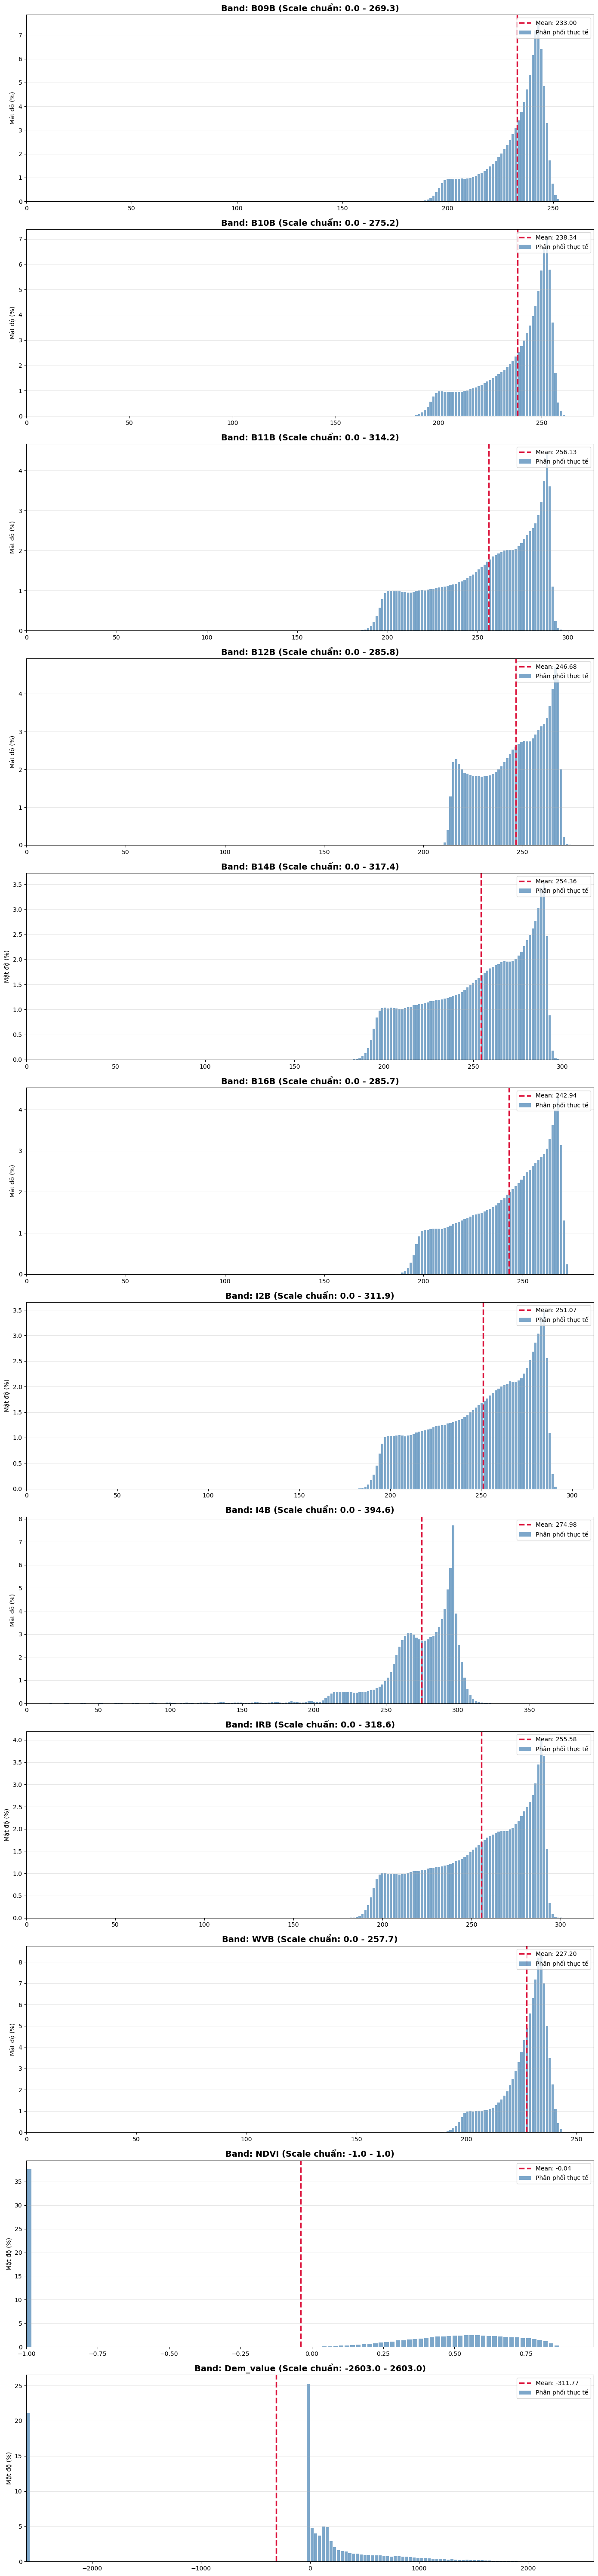

Xong! Ảnh đã lưu tại: /sdd/Dubaoset/src/Thang/dataStatistic/NewTeacher/Output/val_comparison_report.png


In [16]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import json

# ── 1. Thiết lập kết nối ──
con = duckdb.connect()
con.execute("SET memory_limit='30GB'")
con.execute("SET threads=8")

# Đường dẫn file Stats của Train (Vẫn cần để lấy Min/Max chuẩn)
train_stats_path = '/sdd/Dubaoset/src/Thang/dataStatistic/NewTeacher/total_scales.json'
val_plot_output = '/sdd/Dubaoset/src/Thang/dataStatistic/NewTeacher/Output/val_comparison_report.png'

with open(train_stats_path, 'r') as f:
    train_stats_data = json.load(f)

# Giả định listFile đã được định nghĩa
file_list_str = ", ".join([f"'{f}'" for f in listFile])
bandName = ['B09B','B10B','B11B','B12B','B14B','B16B','I2B','I4B','IRB','WVB', 'NDVI','Dem_value']

hist_results = {}

# ── 2. Tính toán Stats & Histogram ──
for band in bandName:
    print(f"Đang xử lý Band: {band}...")
    
    # 2.1 Logic trượt cửa sổ
    all_window_queries = []
    for i in range(6):
        window_start, window_end = -6 + i, i
        for t_val in range(window_start, window_end):
            col_name = band if band in ("Dem_value", "DEMIsLand") else f"{band}_t{('-' + str(-t_val)) if t_val < 0 else ('+' + str(t_val))}"
            all_window_queries.append(f'SELECT "{col_name}" AS val FROM read_parquet([{file_list_str}])')

    union_parts = "\n    UNION ALL\n    ".join(all_window_queries)

    # 2.2 Lấy Min/Max chuẩn và tính Mean thực tế
    min_val = train_stats_data[band]['min']
    max_val = train_stats_data[band]['max']
    val_range = max_val - min_val

    # Tính Mean và Total Rows trong 1 lần quét
    stats_res = con.execute(f"SELECT COUNT(*), AVG(val) FROM ({union_parts}) WHERE val IS NOT NULL").fetchone()
    total_rows, avg_val = stats_res[0], stats_res[1]

    # 2.3 Tính Histogram
    n_bins = 100 if band == 'NDVI' else (150 if band == 'Dem_value' else 200)
    hist_sql = f"""
    SELECT 
        floor((val - {min_val}) / (NULLIF({val_range}, 0)) * ({n_bins} - 1)) as bin_idx,
        COUNT(*) as cnt
    FROM ({union_parts})
    WHERE val BETWEEN {min_val} AND {max_val}
    GROUP BY 1 ORDER BY 1
    """
    h_df = con.execute(hist_sql).df()
    h_df['density_pct'] = (h_df['cnt'] * 100.0 / total_rows) if total_rows > 0 else 0

    hist_results[band] = {'df': h_df, 'min': min_val, 'max': max_val, 'mean': avg_val, 'n_bins': n_bins}

# ── 3. Vẽ đồ thị ──
fig, axes = plt.subplots(len(bandName), 1, figsize=(14, 5 * len(bandName)))
if len(bandName) == 1: axes = [axes]

for ax, band in zip(axes, bandName):
    res = hist_results[band]
    b_min, b_max = res['min'], res['max']
    bin_width = (b_max - b_min) / res['n_bins']
    
    # Vẽ Histogram
    centers = b_min + (res['df']['bin_idx'] + 0.5) * bin_width
    ax.bar(centers, res['df']['density_pct'], width=bin_width * 0.8, color="steelblue", alpha=0.7, label="Phân phối thực tế")
    
    # Kẻ đường Mean
    if res['mean'] is not None:
        ax.axvline(res['mean'], color="crimson", linestyle="--", linewidth=2.5, 
                   label=f"Mean: {res['mean']:.2f}")

    # Định dạng trục
    ax.set_xlim(b_min, b_max)
    ax.set_title(f"Band: {band} (Scale chuẩn: {b_min:.1f} - {b_max:.1f})", fontsize=14, fontweight='bold')
    ax.set_ylabel("Mật độ (%)")
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.savefig(val_plot_output, dpi=150)
plt.show()

print(f"Xong! Ảnh đã lưu tại: {val_plot_output}")

# Sau chuẩn hóa

Đang xử lý Band: B09B...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Đang xử lý Band: B10B...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Đang xử lý Band: Dem_value...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

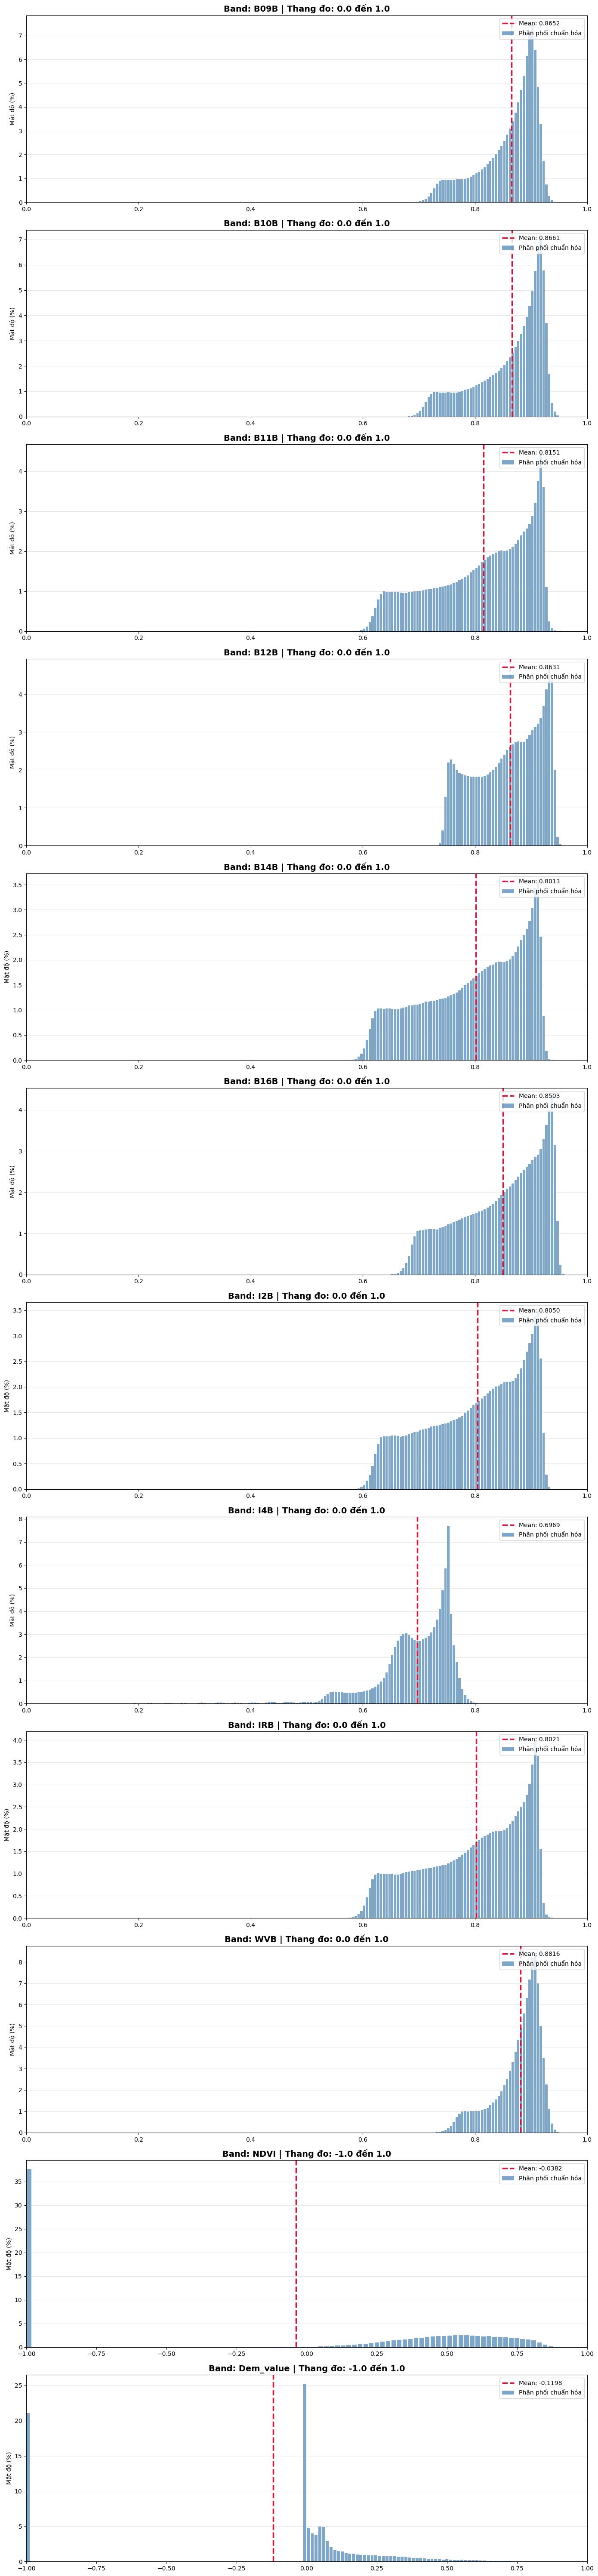

In [18]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import json

# ── 1. Thiết lập kết nối ──
con = duckdb.connect()
con.execute("SET memory_limit='30GB'")
con.execute("SET threads=8")

# Đường dẫn file
train_stats_path = '/sdd/Dubaoset/src/Thang/dataStatistic/NewTeacher/total_scales.json'
val_plot_output = '/sdd/Dubaoset/src/Thang/dataStatistic/NewTeacher/Output/val_comparison_report_norm.png'

with open(train_stats_path, 'r') as f:
    train_stats_data = json.load(f)

# Giả định listFile đã được định nghĩa
file_list_str = ", ".join([f"'{f}'" for f in listFile])
bandName = ['B09B','B10B','B11B','B12B','B14B','B16B','I2B','I4B','IRB','WVB', 'NDVI','Dem_value']

hist_results = {}

# ── 2. Tính toán Stats & Histogram ──
for band in bandName:
    print(f"Đang xử lý Band: {band}...")
    
    # Lấy thông số gốc từ tập Train
    raw_min = train_stats_data[band]['min']
    raw_max = train_stats_data[band]['max']
    raw_range = raw_max - raw_min

    # Xác định công thức chuẩn hóa và thang đo (X-axis)
    if band == 'NDVI':
        # Giữ nguyên bản
        display_min, display_max = -1.0, 1.0
        sql_val_expr = 'val'
    elif band == 'Dem_value':
        # Chuẩn hóa Max (về dải -1 đến 1)
        display_min, display_max = -1.0, 1.0
        # Chia cho trị tuyệt đối của Max để đưa về dải [-1, 1]
        sql_val_expr = f"val / {abs(raw_max)}" 
    else:
        # 10 Bands đầu: Min-Max chuẩn hóa về 0-1
        display_min, display_max = 0.0, 1.0
        sql_val_expr = f"(val - {raw_min}) / NULLIF({raw_range}, 0)"

    display_range = display_max - display_min

    # 2.1 Tạo Union query cho Sliding Window
    all_window_queries = []
    for i in range(6):
        window_start, window_end = -6 + i, i
        for t_val in range(window_start, window_end):
            col_name = band if band in ("Dem_value", "DEMIsLand") else f"{band}_t{('-' + str(-t_val)) if t_val < 0 else ('+' + str(t_val))}"
            all_window_queries.append(f'SELECT "{col_name}" AS val FROM read_parquet([{file_list_str}])')

    union_parts = "\n    UNION ALL\n    ".join(all_window_queries)

    # 2.2 Tính Mean và Total Rows trên giá trị ĐÃ CHUẨN HÓA
    stats_query = f"""
        SELECT COUNT(*), AVG({sql_val_expr}) 
        FROM ({union_parts}) 
        WHERE val IS NOT NULL 
          AND val BETWEEN {raw_min} AND {raw_max}
    """
    stats_res = con.execute(stats_query).fetchone()
    total_rows, scaled_mean = stats_res[0], stats_res[1]

    # 2.3 Tính Histogram trên giá trị ĐÃ CHUẨN HÓA
    n_bins = 100 if band == 'NDVI' else (150 if band == 'Dem_value' else 200)
    
    hist_sql = f"""
    SELECT 
        floor(({sql_val_expr} - {display_min}) / (NULLIF({display_range}, 0)) * ({n_bins} - 1)) as bin_idx,
        COUNT(*) as cnt
    FROM ({union_parts})
    WHERE val BETWEEN {raw_min} AND {raw_max}
    GROUP BY 1 ORDER BY 1
    """
    h_df = con.execute(hist_sql).df()
    h_df['density_pct'] = (h_df['cnt'] * 100.0 / total_rows) if total_rows > 0 else 0

    hist_results[band] = {
        'df': h_df, 
        'min': display_min, 
        'max': display_max, 
        'mean': scaled_mean, 
        'n_bins': n_bins
    }

# ── 3. Vẽ đồ thị ──
fig, axes = plt.subplots(len(bandName), 1, figsize=(14, 5 * len(bandName)))
if len(bandName) == 1: axes = [axes]

for ax, band in zip(axes, bandName):
    res = hist_results[band]
    b_min, b_max = res['min'], res['max']
    bin_width = (b_max - b_min) / res['n_bins']
    
    centers = b_min + (res['df']['bin_idx'] + 0.5) * bin_width
    ax.bar(centers, res['df']['density_pct'], width=bin_width * 0.8, color="steelblue", alpha=0.7, label="Phân phối chuẩn hóa")
    
    if res['mean'] is not None:
        ax.axvline(res['mean'], color="crimson", linestyle="--", linewidth=2.5, 
                   label=f"Mean: {res['mean']:.4f}")

    ax.set_xlim(b_min, b_max)
    ax.set_title(f"Band: {band} | Thang đo: {b_min} đến {b_max}", fontsize=14, fontweight='bold')
    ax.set_ylabel("Mật độ (%)")
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig(val_plot_output, dpi=150)
plt.show()

>>> Đang phân tích Validation cho Band: B09B...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

>>> Đang phân tích Validation cho Band: B10B...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

>>> Đang phân tích Validation cho Band: Dem_value...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Hoàn thành! Biểu đồ lưu tại: /sdd/Dubaoset/src/Thang/dataStatistic/NewTeacher/Output/val_comparison_report_0_1.png


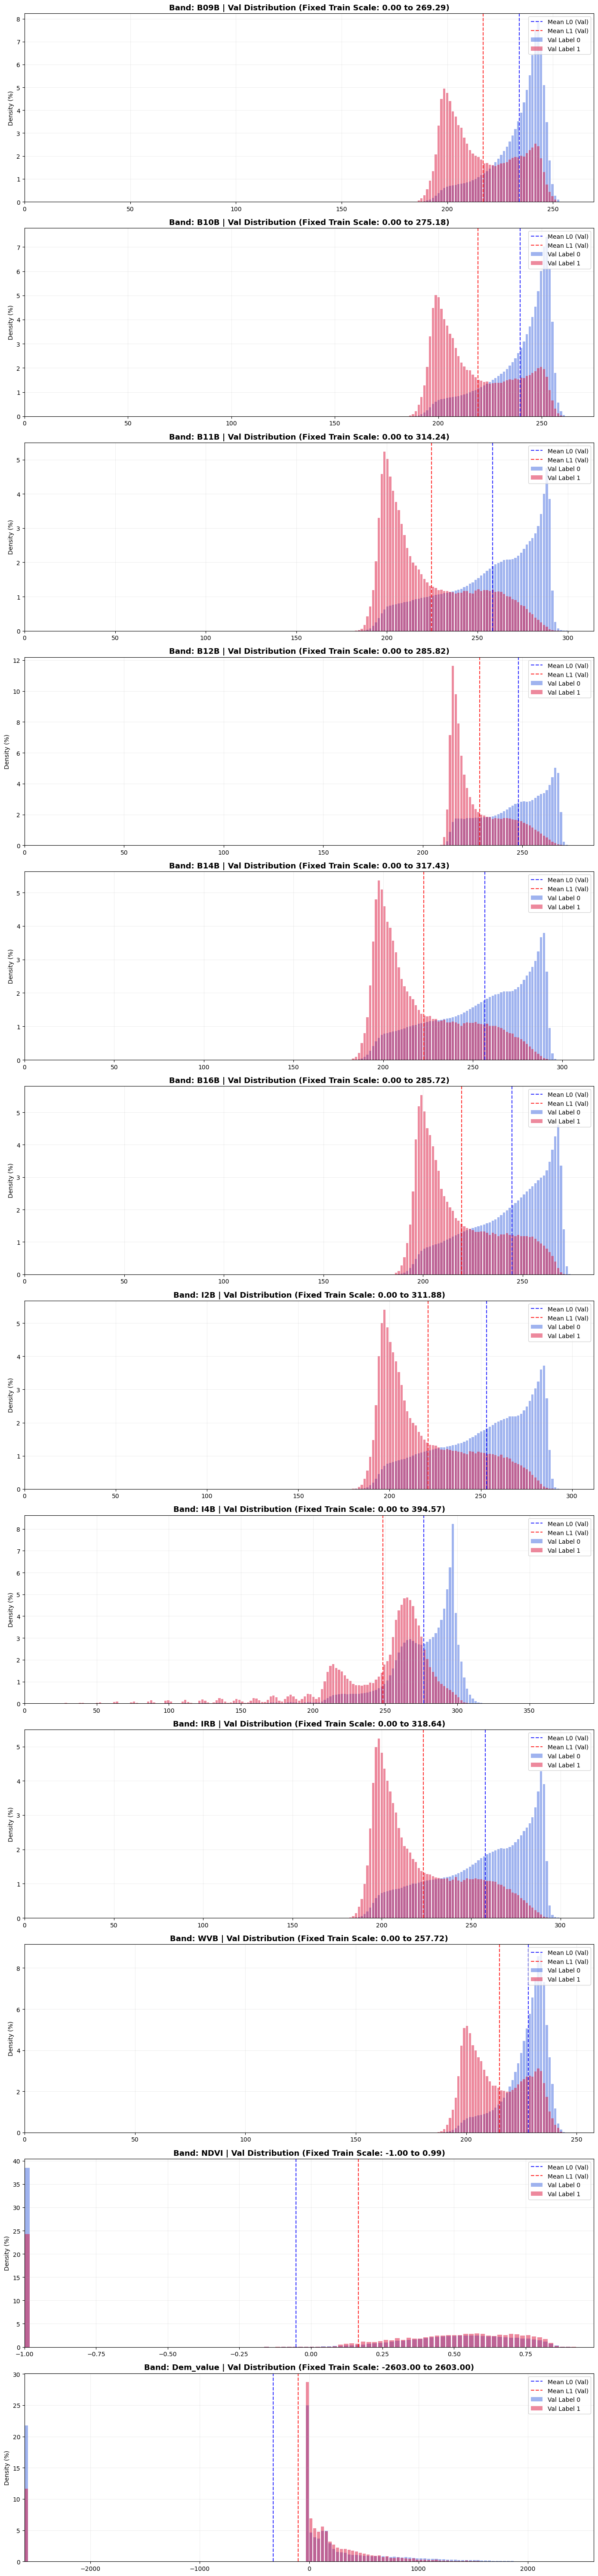

In [3]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import json
import os

# ── 1. Thiết lập kết nối ──
con = duckdb.connect()
con.execute("SET memory_limit='32GB'")
con.execute("SET threads=16") # Tận dụng tối đa CPU

# Đường dẫn file
train_stats_path = '/sdd/Dubaoset/src/Thang/dataStatistic/NewTeacher/total_scales.json'
val_json_output = '/sdd/Dubaoset/src/Thang/dataStatistic/NewTeacher/Output/val_detailed_stats_0_1.json'
val_plot_output = '/sdd/Dubaoset/src/Thang/dataStatistic/NewTeacher/Output/val_comparison_report_0_1.png'
VAL_PATH = "/sdd/Dubaoset/src/Phong/Model/data/validation/clean_eval_data_6.parquet"
listFile = [VAL_PATH]

# Load thông số Train (Lấy Min/Max làm mốc chuẩn)
with open(train_stats_path, 'r') as f:
    train_stats_data = json.load(f)

# Giả định listFile đã được lấy từ thư mục Validation
file_list_str = ", ".join([f"'{f}'" for f in listFile])
bandName = ['B09B','B10B','B11B','B12B','B14B','B16B','I2B','I4B','IRB','WVB', 'NDVI','Dem_value']

detailed_stats_json = {}
hist_results = {}

# ── 2. Tính toán Stats & Histogram ──
for band in bandName:
    print(f">>> Đang phân tích Validation cho Band: {band}...")
    
    # 2.1 Tạo logic trượt cửa sổ (Sliding Window) 
    # Kết hợp 6 output với các window tương ứng
    all_window_queries = []
    for i in range(6):
        label_col = f"output_{i}"
        window_start = -6 + i
        window_end = window_start + 6 
        for t_val in range(window_start, window_end):
            if band in ("Dem_value", "DEMIsLand"):
                col_name = band
            else:
                t_str = f"t{('-' + str(-t_val)) if t_val < 0 else ('+' + str(t_val))}"
                col_name = f"{band}_{t_str}"
            
            # Gộp dữ liệu: mỗi dòng kèm theo nhãn thời điểm tương ứng
            all_window_queries.append(
                f'SELECT "{col_name}" AS val, "{label_col}" AS label FROM read_parquet([{file_list_str}])'
            )

    union_parts = "\n    UNION ALL\n    ".join(all_window_queries)
    
    # 2.2 Tính Stats thực tế của tập Validation (Sử dụng SAMPLE 10% nếu dữ liệu quá khổng lồ)
    # Ở đây tôi tính trực tiếp để đảm bảo độ chính xác cho JSON
    stats_label_query = f"""
    SELECT
        label,
        COUNT(*) AS total_rows,
        MIN(val) AS min_val,
        MAX(val) AS max_val,
        AVG(val) AS mean_val
    FROM ({union_parts})
    WHERE val IS NOT NULL
    GROUP BY label
    """
    try:
        s_label_df = con.execute(stats_label_query).df().set_index('label')
    except Exception as e:
        print(f"Lỗi khi đọc band {band}: {e}")
        continue
    
    # Lưu stats thực tế của Validation vào dict
    val_band_stats = {}
    for lbl in [0, 1]:
        if lbl in s_label_df.index:
            row = s_label_df.loc[lbl]
            val_band_stats[f"label_{lbl}"] = {
                'total_rows': int(row['total_rows']),
                'min': float(row['min_val']),
                'max': float(row['max_val']),
                'mean': float(row['mean_val'])
            }
        else:
            val_band_stats[f"label_{lbl}"] = {'total_rows': 0, 'min': 0, 'max': 0, 'mean': 0}
    
    detailed_stats_json[band] = val_band_stats

    # 2.3 Lấy khung đo (Scale) từ tập TRAIN (Sử dụng Min/Max làm mốc)
    # Logic: Lấy Min nhỏ nhất và Max lớn nhất giữa 2 nhãn của Train để làm trục X
    t_min = train_stats_data[band]['min']
    t_max = train_stats_data[band]['max']

    val_range = t_max - t_min
    
    detailed_stats_json[band]['train_scale_used'] = {'min': t_min, 'max': t_max}

    # 2.4 Tính Histogram cho Validation dựa trên khung đo của Train
    n_bins = 100 if band == 'NDVI' else (150 if band == 'Dem_value' else 200)
        
    hist_sql = f"""
    SELECT 
        label,
        floor((val - {t_min}) / (NULLIF({val_range}, 0)) * ({n_bins} - 1)) as bin_idx,
        COUNT(*) as cnt
    FROM ({union_parts})
    WHERE val BETWEEN {t_min} AND {t_max}
    GROUP BY 1, 2 ORDER BY 2
    """
    h_df = con.execute(hist_sql).df()

    # Tính mật độ % dựa trên tổng số dòng của từng nhãn trong Validation
    res_band = {'n_bins': n_bins, 'scale_min': t_min, 'scale_max': t_max}
    for lbl in [0, 1]:
        df_lbl = h_df[h_df['label'] == lbl].copy()
        total_lbl = val_band_stats[f"label_{lbl}"]['total_rows']
        df_lbl['density_pct'] = df_lbl['cnt'] * 100.0 / total_lbl if total_lbl > 0 else 0
        res_band[f'df{lbl}'] = df_lbl
        
    hist_results[band] = res_band

# ── 3. Lưu và Vẽ ──
with open(val_json_output, 'w') as f:
    json.dump(detailed_stats_json, f, indent=4)

fig, axes = plt.subplots(len(bandName), 1, figsize=(14, 5 * len(bandName)))
if len(bandName) == 1: axes = [axes]

for ax, band in zip(axes, bandName):
    res = hist_results[band]
    s_min, s_max = res['scale_min'], res['scale_max']
    bin_width = (s_max - s_min) / res['n_bins']
    
    # Vẽ Nhãn 0
    if not res['df0'].empty:
        c0 = s_min + (res['df0']['bin_idx'] + 0.5) * bin_width
        ax.bar(c0, res['df0']['density_pct'], width=bin_width*0.8, color="royalblue", alpha=0.5, label="Val Label 0")
    
    # Vẽ Nhãn 1
    if not res['df1'].empty:
        c1 = s_min + (res['df1']['bin_idx'] + 0.5) * bin_width
        ax.bar(c1, res['df1']['density_pct'], width=bin_width*0.8, color="crimson", alpha=0.5, label="Val Label 1")
    
    # Kẻ Mean của Validation (đường nét đứt)
    ax.axvline(detailed_stats_json[band]['label_0']['mean'], color="blue", linestyle="--", alpha=0.8, label="Mean L0 (Val)")
    ax.axvline(detailed_stats_json[band]['label_1']['mean'], color="red", linestyle="--", alpha=0.8, label="Mean L1 (Val)")
    
    ax.set_xlim(s_min, s_max)
    ax.set_title(f"Band: {band} | Val Distribution (Fixed Train Scale: {s_min:.2f} to {s_max:.2f})", fontsize=13, fontweight='bold')
    ax.set_ylabel("Density (%)")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(val_plot_output, dpi=150)
print(f"Hoàn thành! Biểu đồ lưu tại: {val_plot_output}")